# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [28]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [29]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



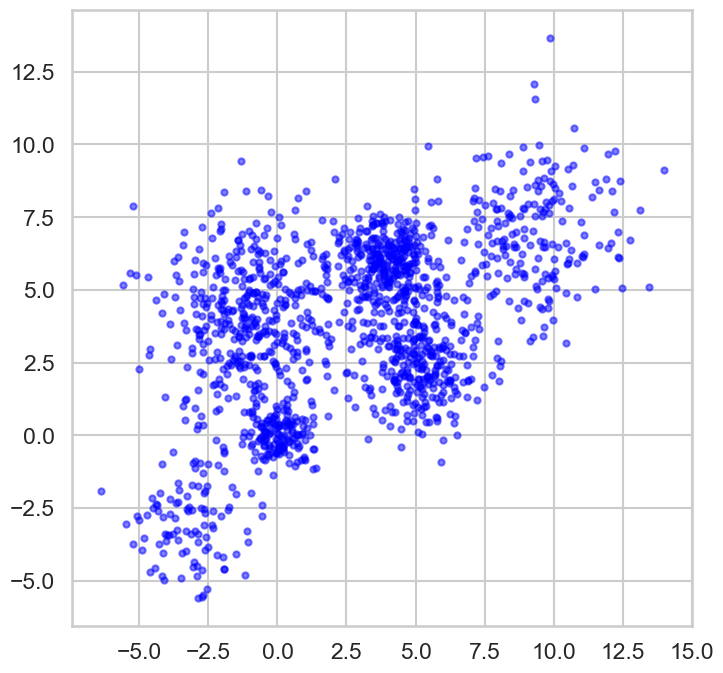

In [30]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

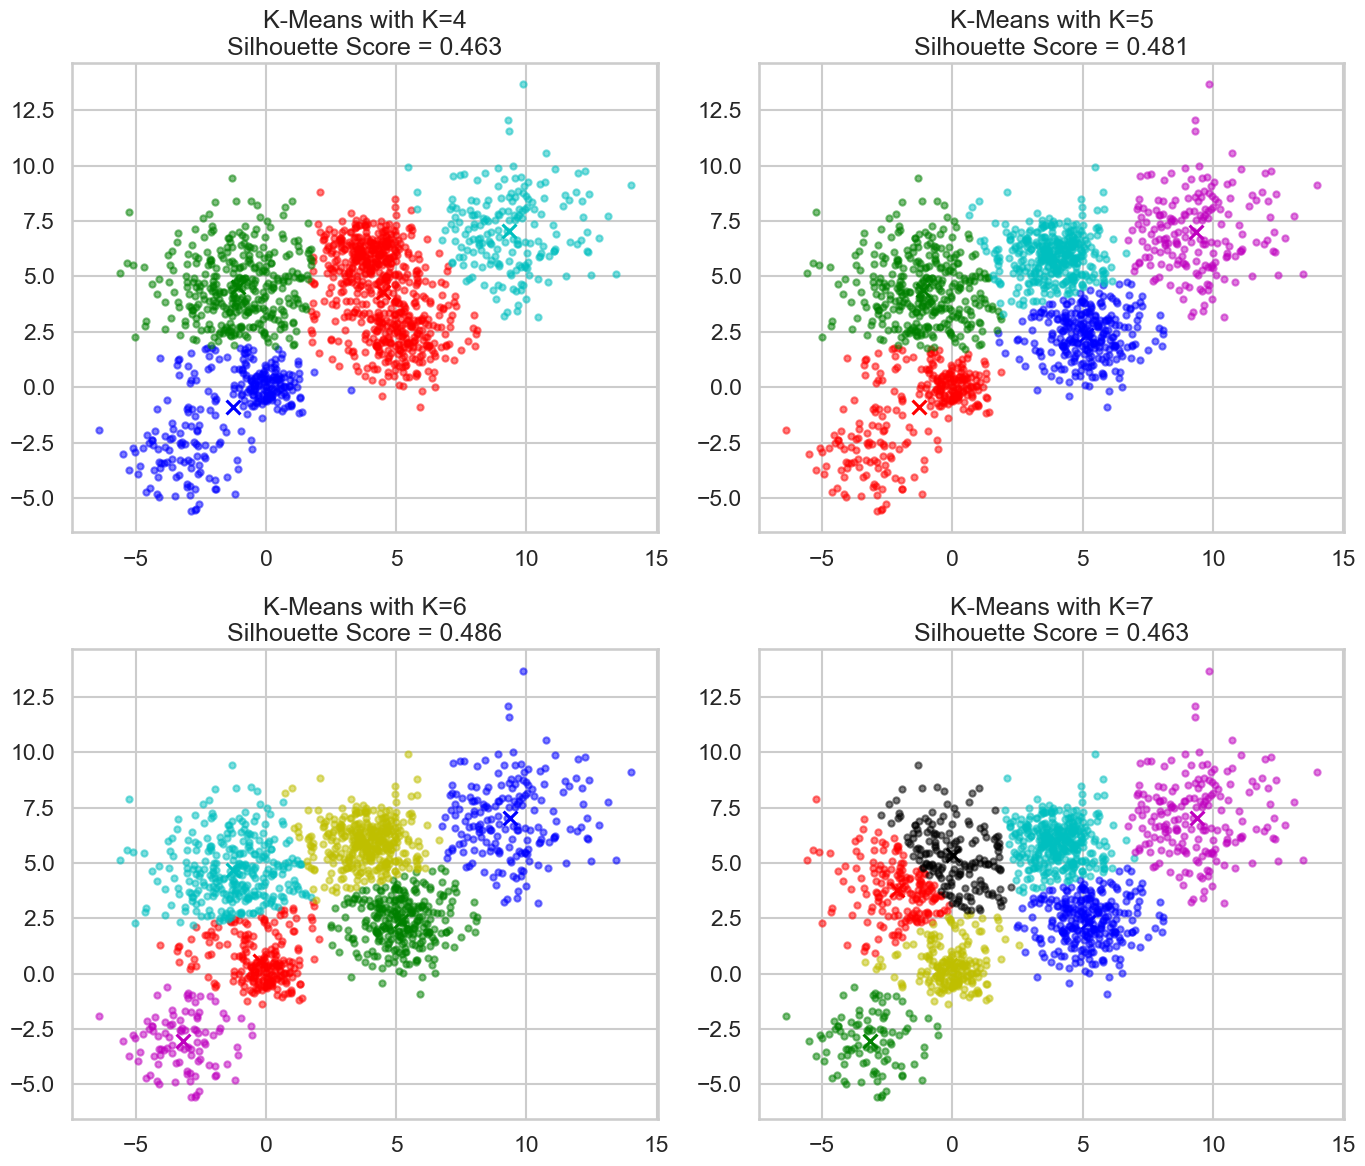

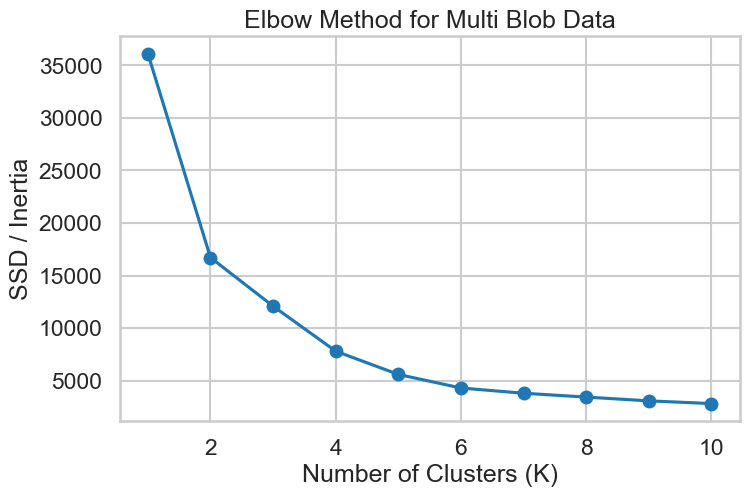

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Try different K values
k_values = [4, 5, 6, 7]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, k in enumerate(k_values):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Multi_blob_Data)

    sil = silhouette_score(Multi_blob_Data, km.labels_)

    plt.sca(axes[i // 2, i % 2])
    display_cluster(Multi_blob_Data, km, k)
    plt.title(f'K-Means with K={k}\nSilhouette Score = {sil:.3f}')

plt.tight_layout()
plt.show()

# Elbow method
ssd = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Multi_blob_Data)
    ssd.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, ssd, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSD / Inertia")
plt.title("Elbow Method for Multi Blob Data")
plt.show()

### Comment on K-Means for Multi Blob Data

K-Means performs well on this dataset because the data was generated as compact blob-like groups, which matches the assumptions of K-Means.

By comparing different values of K, we notice that:
- When K is too small, some true groups are merged together.
- When K is too large, some natural groups are split unnecessarily.
- Around K = 6, the clustering becomes most consistent with the known structure of the dataset.

The Elbow plot should also suggest a bend around K = 6, which supports selecting 6 clusters.


### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

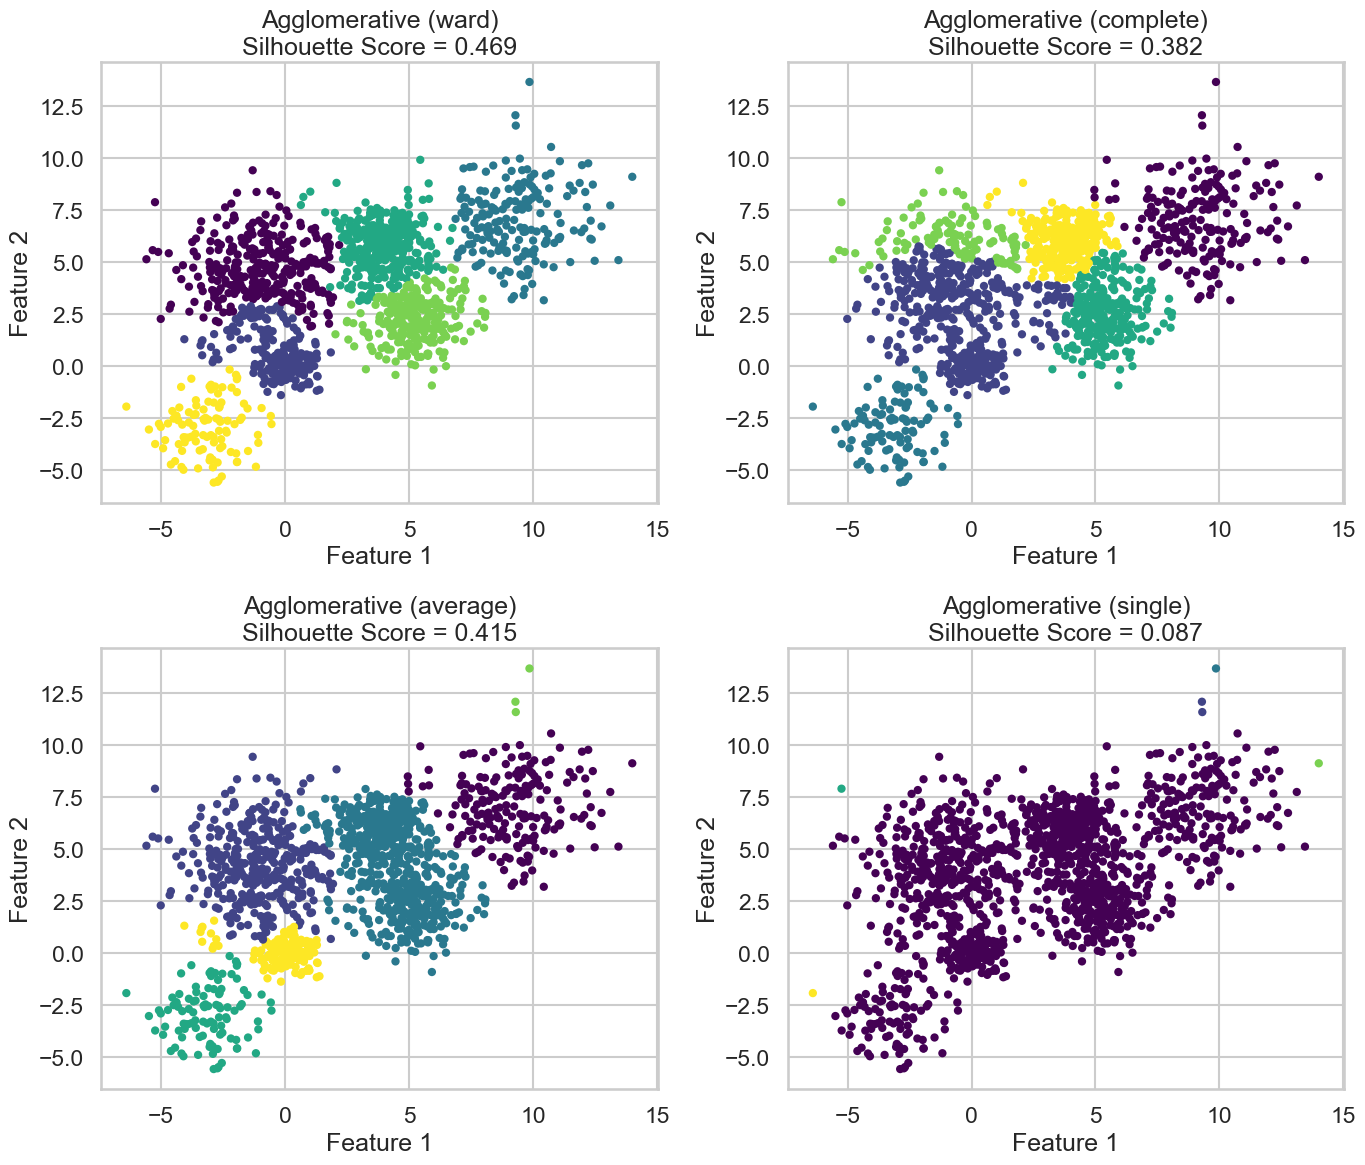

In [32]:
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, linkage in enumerate(linkages):
    agg = AgglomerativeClustering(n_clusters=6, linkage=linkage)
    labels = agg.fit_predict(Multi_blob_Data)

    sil = silhouette_score(Multi_blob_Data, labels)

    plt.sca(axes[i // 2, i % 2])
    plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=labels, cmap='viridis', s=20)
    plt.title(f'Agglomerative ({linkage})\nSilhouette Score = {sil:.3f}')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Comment on Hierarchical Clustering for Multi Blob Data

Agglomerative clustering also performs well on the Multi Blob dataset, especially with linkage methods such as `ward` and `average`.

Observations:
- `ward` usually gives compact and balanced clusters and is often the best choice for blob-like numeric data.
- `complete` may separate clusters well but can be sensitive to extreme points.
- `average` gives a compromise between methods.
- `single` often performs poorly because it can create chain-like clusters.

Overall, hierarchical clustering is able to recover the cluster structure, but the quality depends strongly on the linkage method.

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

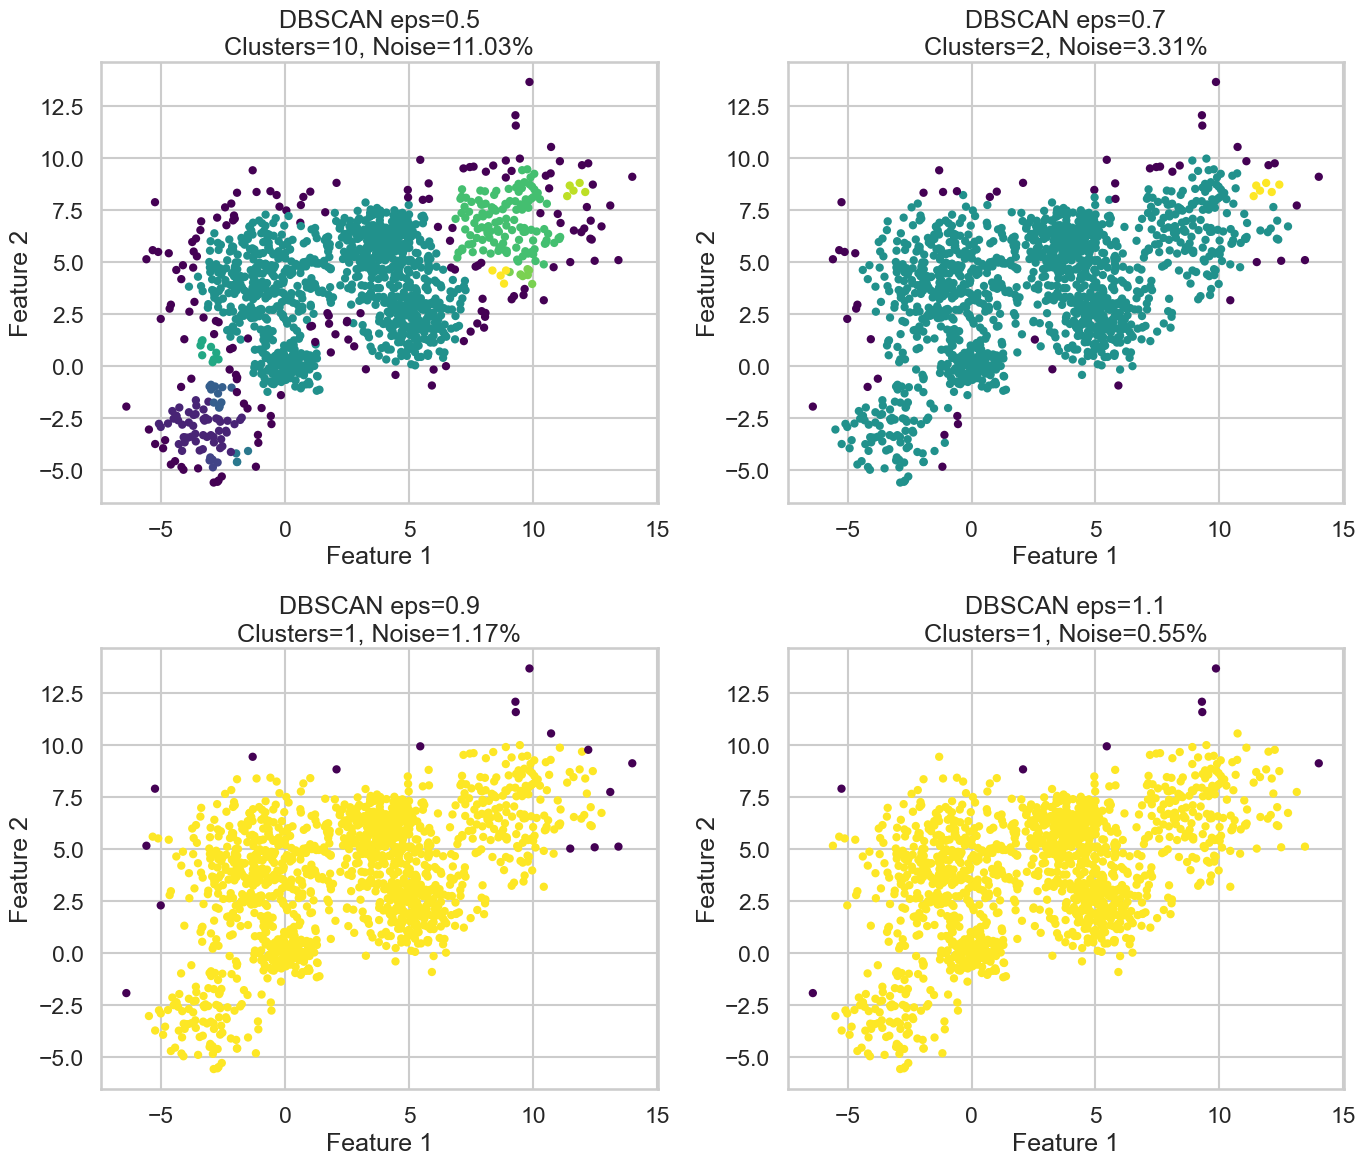

In [33]:
from sklearn.cluster import DBSCAN
import numpy as np

eps_values = [0.5, 0.7, 0.9, 1.1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(Multi_blob_Data)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    plt.sca(axes[i // 2, i % 2])
    plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=labels, cmap='viridis', s=20)
    plt.title(f'DBSCAN eps={eps}\nClusters={n_clusters}, Noise={noise_ratio:.2%}')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Comment on DBSCAN for Multi Blob Data

DBSCAN groups points based on density rather than distance to a centroid.

Observations:
- For small values of `eps`, DBSCAN may create too many small clusters or label many points as noise.
- For large values of `eps`, DBSCAN may merge several groups into a single large cluster.
- DBSCAN can work well when clusters are clearly separated by density, but it is sensitive to the choice of `eps` and `min_samples`.

In this dataset, DBSCAN may not recover the exact 6 blobs as cleanly as K-Means or Agglomerative clustering, especially because the blobs have different densities and spreads.

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [34]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

In [35]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Shape of iris data:", X_iris.shape)
print("Feature names:", iris.feature_names)

Shape of iris data: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


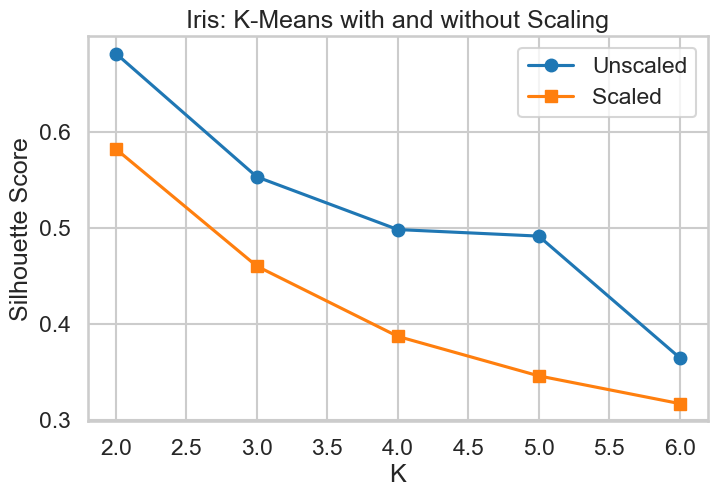

In [36]:
# K-Means without scaling
silhouette_unscaled = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_iris)
    silhouette_unscaled.append(silhouette_score(X_iris, labels))

# K-Means with scaling
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

silhouette_scaled = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_iris_scaled)
    silhouette_scaled.append(silhouette_score(X_iris_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_unscaled, marker='o', label='Unscaled')
plt.plot(k_values, silhouette_scaled, marker='s', label='Scaled')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Iris: K-Means with and without Scaling")
plt.legend()
plt.show()

### Effect of Scaling on Iris Dataset

Scaling changes the contribution of each feature to the distance calculation.

Without scaling:
- Features with larger numeric ranges can dominate clustering.

With scaling:
- All features contribute more equally.

For the Iris dataset, scaling is generally important because K-Means and other distance-based methods depend on Euclidean distance. Even if all features are numeric, their ranges are not exactly the same, so scaling makes the clustering more balanced.

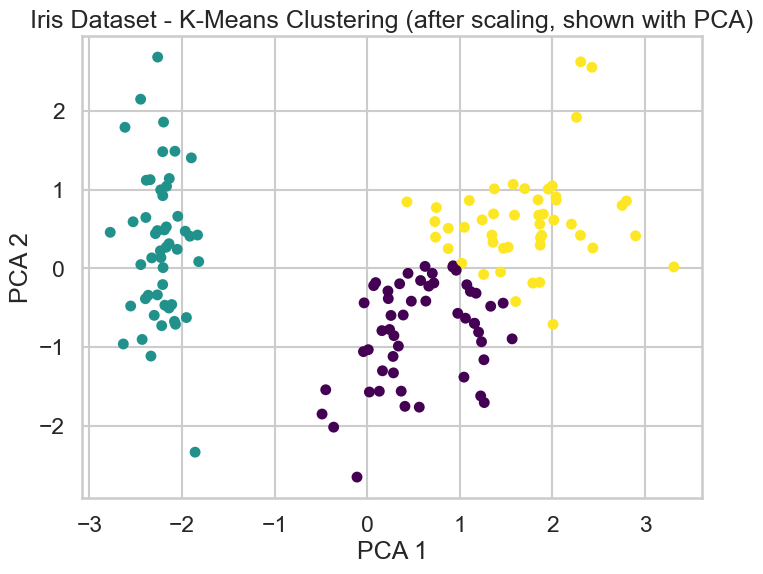

In [37]:
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(X_iris_scaled)

km_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
iris_labels = km_iris.fit_predict(X_iris_scaled)

plt.figure(figsize=(8,6))
plt.scatter(iris_pca[:, 0], iris_pca[:, 1], c=iris_labels, cmap='viridis', s=40)
plt.title("Iris Dataset - K-Means Clustering (after scaling, shown with PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

### Comment on K-Means for Iris

K-Means can identify some natural structure in the Iris dataset, especially one well-separated group. However, it may still confuse the other two groups because they overlap in feature space.

The PCA plot is used only for visualization. The clustering itself is still performed on the full scaled 4-dimensional dataset.

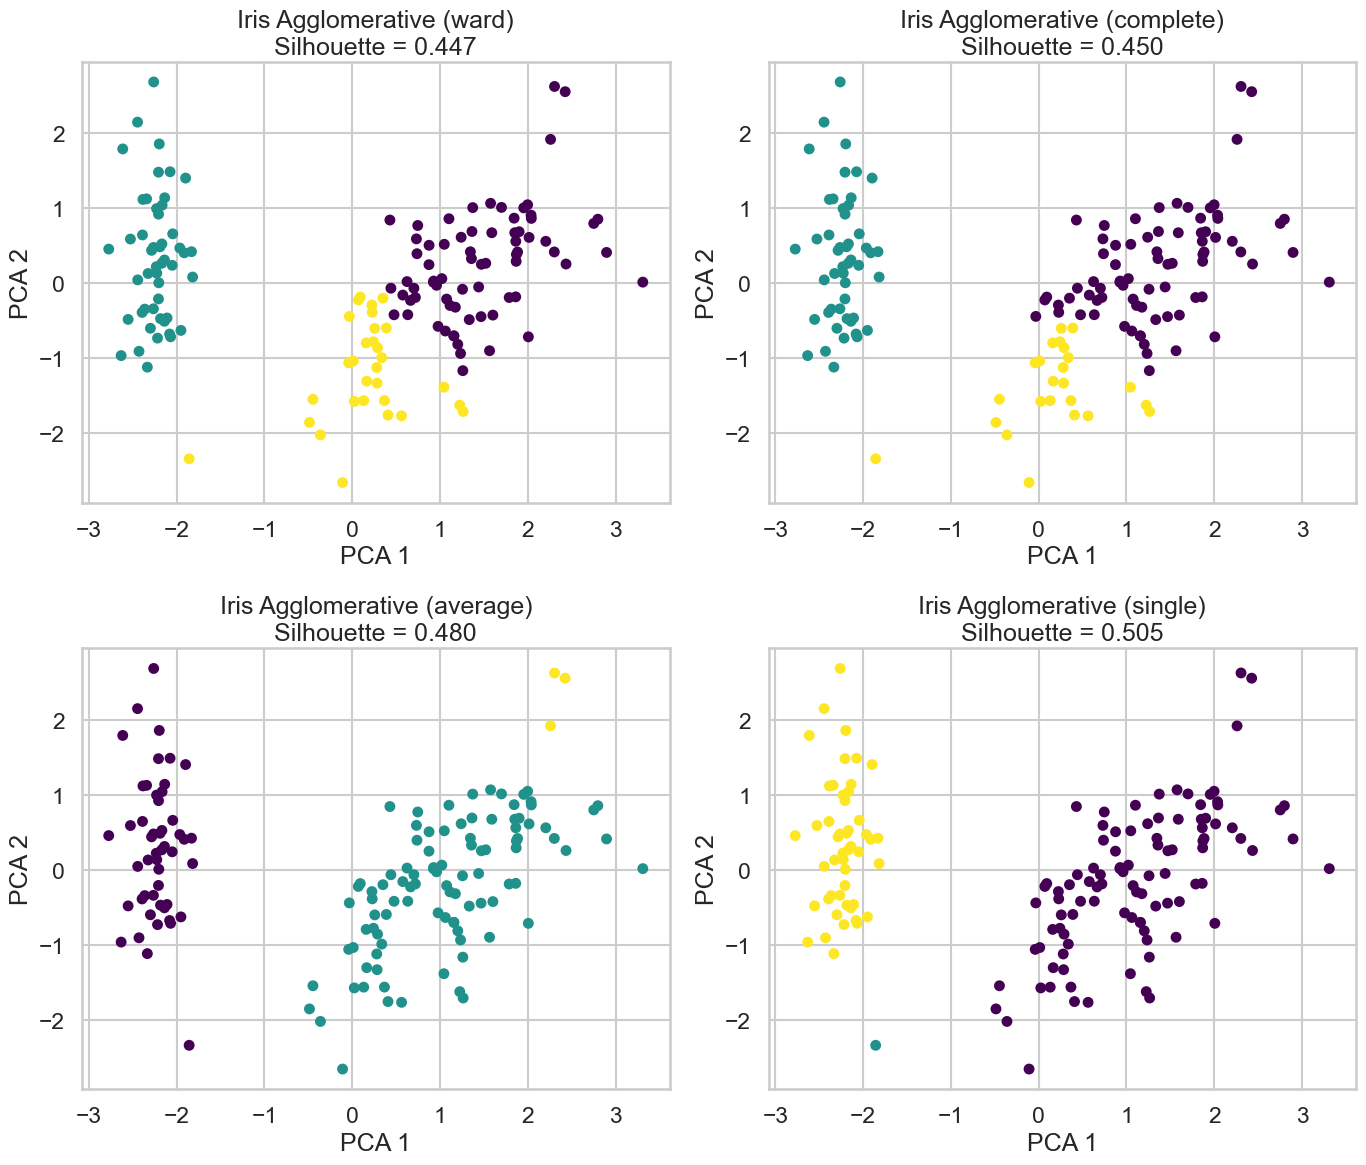

In [38]:
linkages = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, linkage in enumerate(linkages):
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels = agg.fit_predict(X_iris_scaled)

    sil = silhouette_score(X_iris_scaled, labels)

    plt.sca(axes[i // 2, i % 2])
    plt.scatter(iris_pca[:, 0], iris_pca[:, 1], c=labels, cmap='viridis', s=40)
    plt.title(f'Iris Agglomerative ({linkage})\nSilhouette = {sil:.3f}')
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

### Comment on Hierarchical Clustering for Iris

Hierarchical clustering can also separate the Iris dataset reasonably well. The result depends on the linkage method.

In many cases:
- `ward` works well for compact numeric clusters.
- `single` may produce chaining and less stable clusters.
- `average` and `complete` can sometimes give a better visual separation, but this depends on the data.

Compared with K-Means, hierarchical clustering does not require choosing centroids, but it still requires selecting the number of clusters.

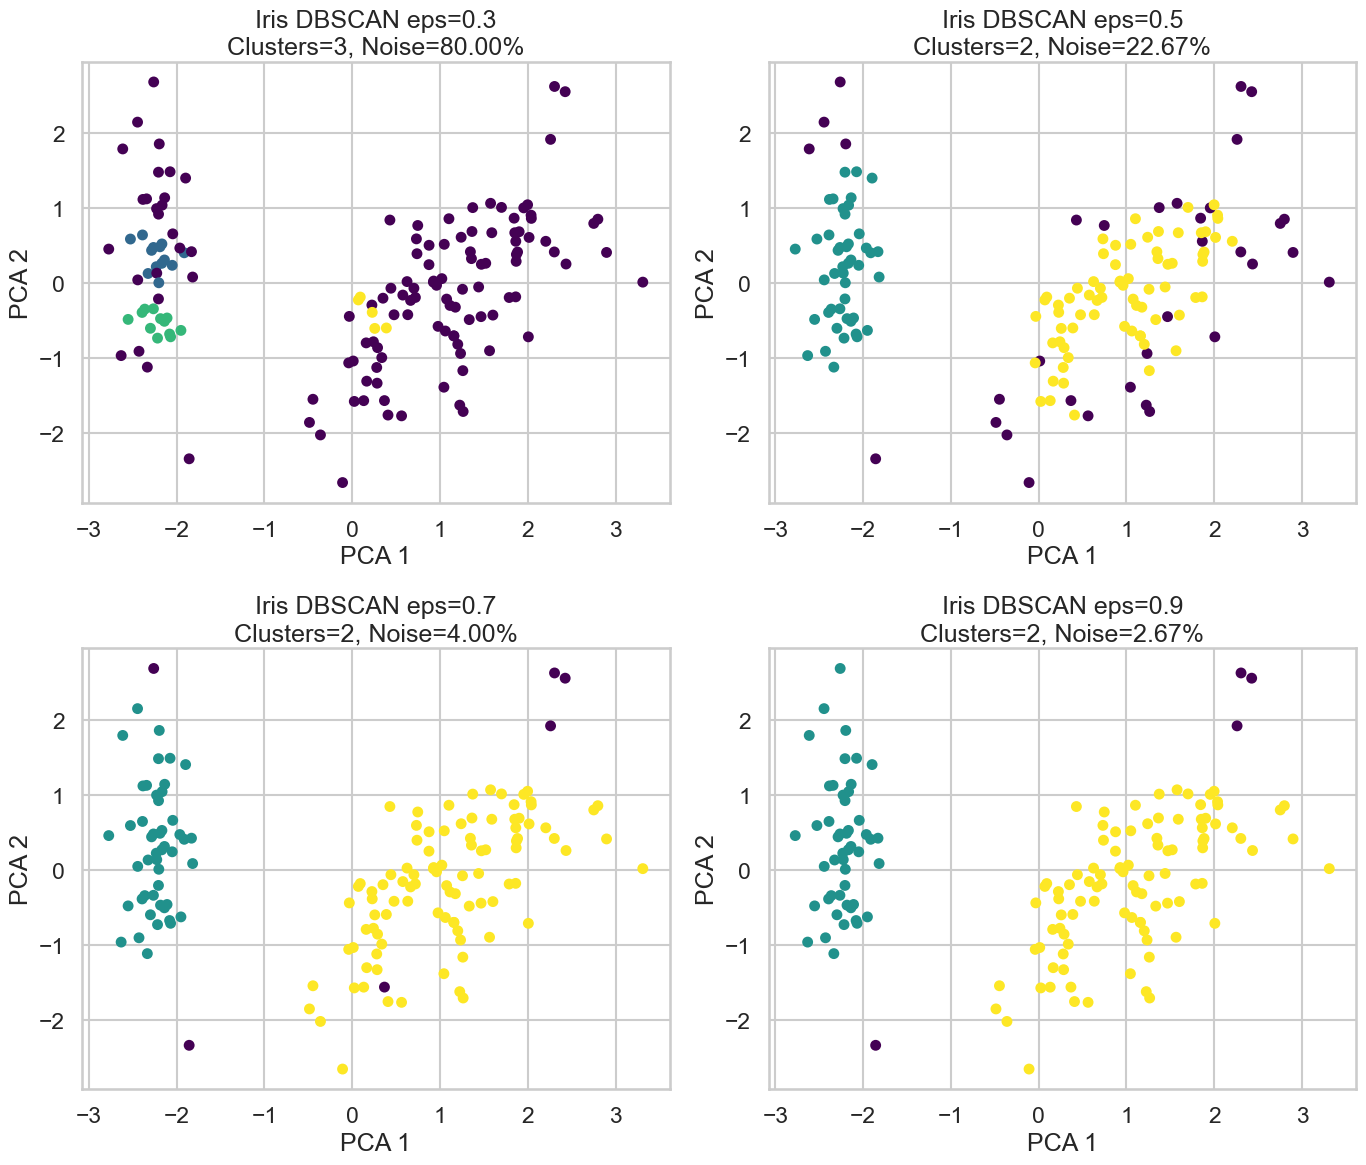

In [39]:
eps_values = [0.3, 0.5, 0.7, 0.9]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_iris_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    plt.sca(axes[i // 2, i % 2])
    plt.scatter(iris_pca[:, 0], iris_pca[:, 1], c=labels, cmap='viridis', s=40)
    plt.title(f'Iris DBSCAN eps={eps}\nClusters={n_clusters}, Noise={noise_ratio:.2%}')
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

### Comment on DBSCAN for Iris

DBSCAN does not require specifying the number of clusters in advance, which is an advantage. However, it is very sensitive to `eps` and `min_samples`.

For the Iris dataset:
- DBSCAN may identify dense groups well.
- It may also merge clusters or mark many points as noise depending on parameter choice.

Compared with K-Means and Hierarchical clustering, DBSCAN is less reliable here because Iris does not contain very strong density-separated groups.

## Customer dataset
Repeat all the above on the customer data set

In [40]:
customer_df = pd.read_csv('Customer data.csv')
customer_df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [41]:
print("Shape:", customer_df.shape)
print("\nMissing values:\n", customer_df.isnull().sum())
print("\nData types:\n", customer_df.dtypes)
customer_df.describe()

Shape: (2000, 8)

Missing values:
 ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

Data types:
 ID                 int64
Sex                int64
Marital status     int64
Age                int64
Education          int64
Income             int64
Occupation         int64
Settlement size    int64
dtype: object


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


### Comment on Customer Dataset

The customer dataset contains demographic and socioeconomic information about customers.

Important observations:
- The `ID` column is only an identifier and should not be used for clustering.
- There are no missing values in the dataset.
- Features such as `Income` and `Age` have very different numerical scales, so scaling is necessary before clustering.

In [42]:
X_customer = customer_df.drop('ID', axis=1)

X_customer_unscaled = X_customer.copy()

scaler = StandardScaler()
X_customer_scaled = scaler.fit_transform(X_customer)

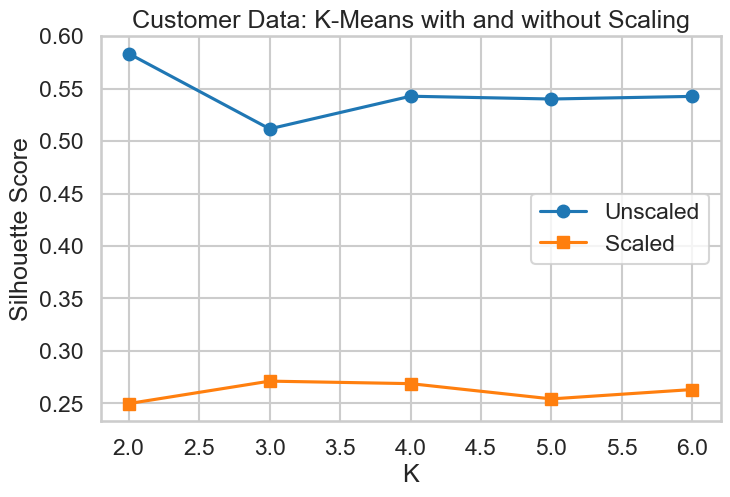

In [43]:
k_values = range(2, 7)
sil_unscaled = []
sil_scaled = []

for k in k_values:
    km_unscaled = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_unscaled = km_unscaled.fit_predict(X_customer_unscaled)
    sil_unscaled.append(silhouette_score(X_customer_unscaled, labels_unscaled))

    km_scaled = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_scaled = km_scaled.fit_predict(X_customer_scaled)
    sil_scaled.append(silhouette_score(X_customer_scaled, labels_scaled))

plt.figure(figsize=(8,5))
plt.plot(k_values, sil_unscaled, marker='o', label='Unscaled')
plt.plot(k_values, sil_scaled, marker='s', label='Scaled')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Customer Data: K-Means with and without Scaling")
plt.legend()
plt.show()

### Effect of Scaling on Customer Dataset

Scaling has a very strong effect here because `Income` has a much larger numerical range than the other variables.

Without scaling:
- clustering may be dominated mainly by income.

With scaling:
- all features contribute more equally.

Therefore, scaled clustering is more meaningful for customer segmentation, even if the silhouette score may become lower than the unscaled case.
A higher unscaled score does not necessarily mean better segmentation; it may just mean one large-scale variable is dominating the distance.

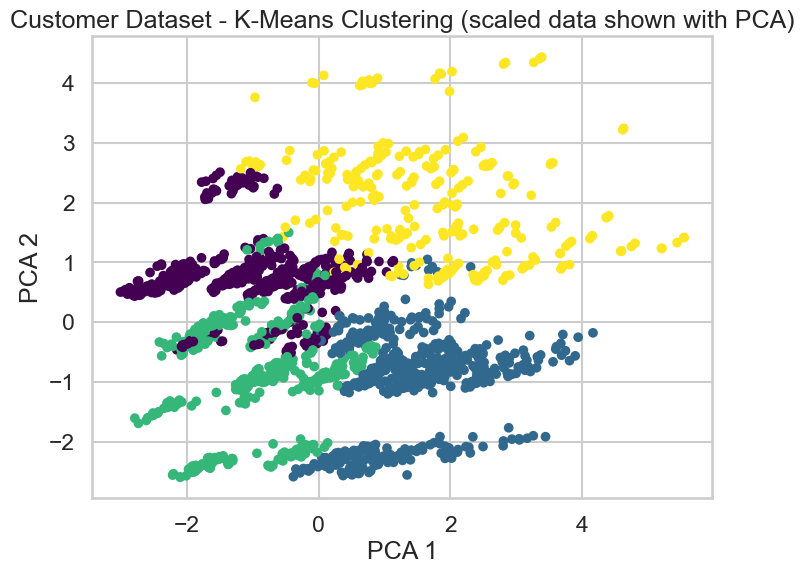

In [44]:
km_customer = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_labels = km_customer.fit_predict(X_customer_scaled)

pca = PCA(n_components=2)
customer_pca = pca.fit_transform(X_customer_scaled)

plt.figure(figsize=(8,6))
plt.scatter(customer_pca[:, 0], customer_pca[:, 1], c=customer_labels, cmap='viridis', s=30)
plt.title("Customer Dataset - K-Means Clustering (scaled data shown with PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

### Comment on K-Means for Customer Data

K-Means can produce useful customer segments after scaling. Since customer features are numeric and represent measurable attributes, K-Means is suitable here.

However:
- the exact number of clusters is subjective,
- different K values may lead to different segmentation interpretations.

A choice such as K = 4 is often reasonable because it gives interpretable groups without over-fragmenting the data.

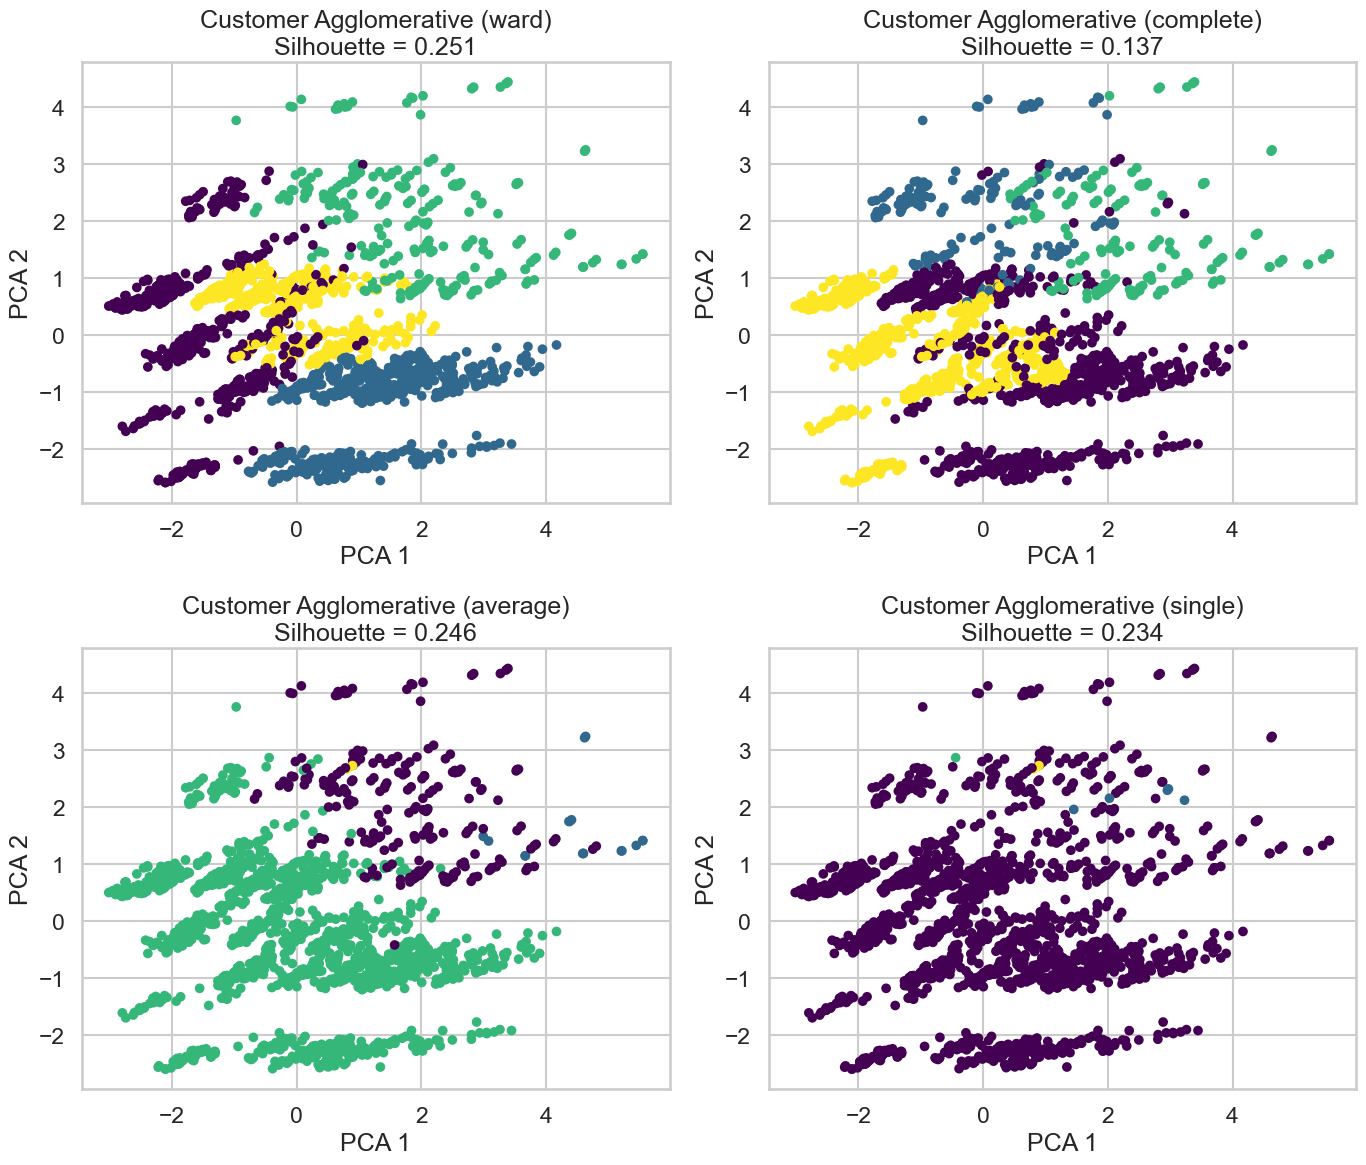

In [45]:
linkages = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for i, linkage in enumerate(linkages):
    agg = AgglomerativeClustering(n_clusters=4, linkage=linkage)
    labels = agg.fit_predict(X_customer_scaled)

    sil = silhouette_score(X_customer_scaled, labels)

    plt.sca(axes[i // 2, i % 2])
    plt.scatter(customer_pca[:, 0], customer_pca[:, 1], c=labels, cmap='viridis', s=30)
    plt.title(f'Customer Agglomerative ({linkage})\nSilhouette = {sil:.3f}')
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

### Comment on Hierarchical Clustering for Customer Data

Hierarchical clustering gives another way to segment customers without relying on centroids.

Observations:
- `ward` usually works best for compact numeric clusters.
- `single` may produce chaining and less useful customer groups.
- `complete` and `average` can give different segment boundaries.

Hierarchical clustering may be useful when we want to explore how groups merge step by step, but for large datasets K-Means is usually more efficient.

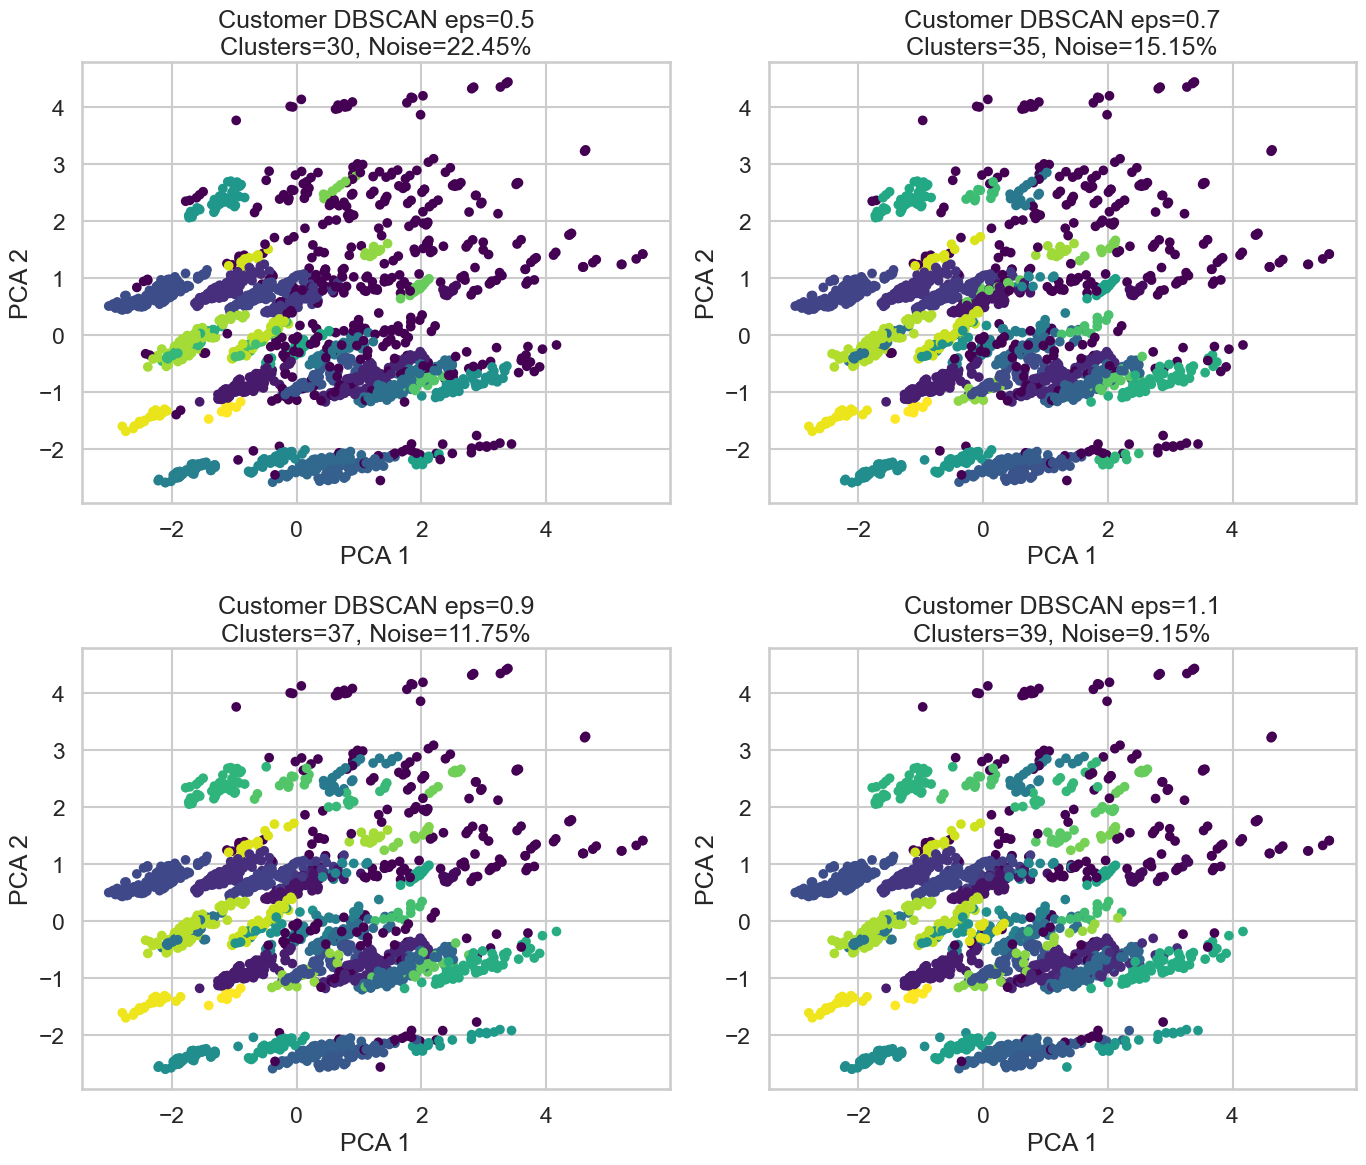

In [48]:
eps_values = [0.5, 0.7, 0.9, 1.1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
max_clusters = 10
for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=8)
    labels = db.fit_predict(X_customer_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    plt.sca(axes[i // 2, i % 2])
    plt.scatter(customer_pca[:, 0], customer_pca[:, 1], c=labels, cmap='viridis', s=30)
    plt.title(f'Customer DBSCAN eps={eps}\nClusters={n_clusters}, Noise={noise_ratio:.2%}')
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

### Comment on DBSCAN for Customer Data

DBSCAN may struggle on customer data because:
- the dataset is not naturally separated into density-based groups,
- the data has several dimensions,
- small changes in `eps` can produce very different numbers of clusters.

DBSCAN is useful when the data contains irregularly shaped dense regions and clear outliers, but for this customer dataset K-Means and Hierarchical clustering are generally more interpretable.

### Overall Comparison on Customer Dataset

- K-Means is a strong choice for customer segmentation after scaling.
- Hierarchical clustering also works, but the result depends on linkage.
- DBSCAN is less stable and more sensitive to parameter tuning.

Scaling is essential for this dataset because features like income would otherwise dominate the clustering process.

eps=0.5: clusters=30, noise=22.45%
eps=0.7: clusters=35, noise=15.15%
eps=0.9: clusters=37, noise=11.75%
eps=1.1: clusters=39, noise=9.15%
eps=1.3: clusters=25, noise=5.15%
eps=1.5: clusters=28, noise=2.45%
eps=1.8: clusters=4, noise=0.75%
eps=2.2: clusters=1, noise=0.10%


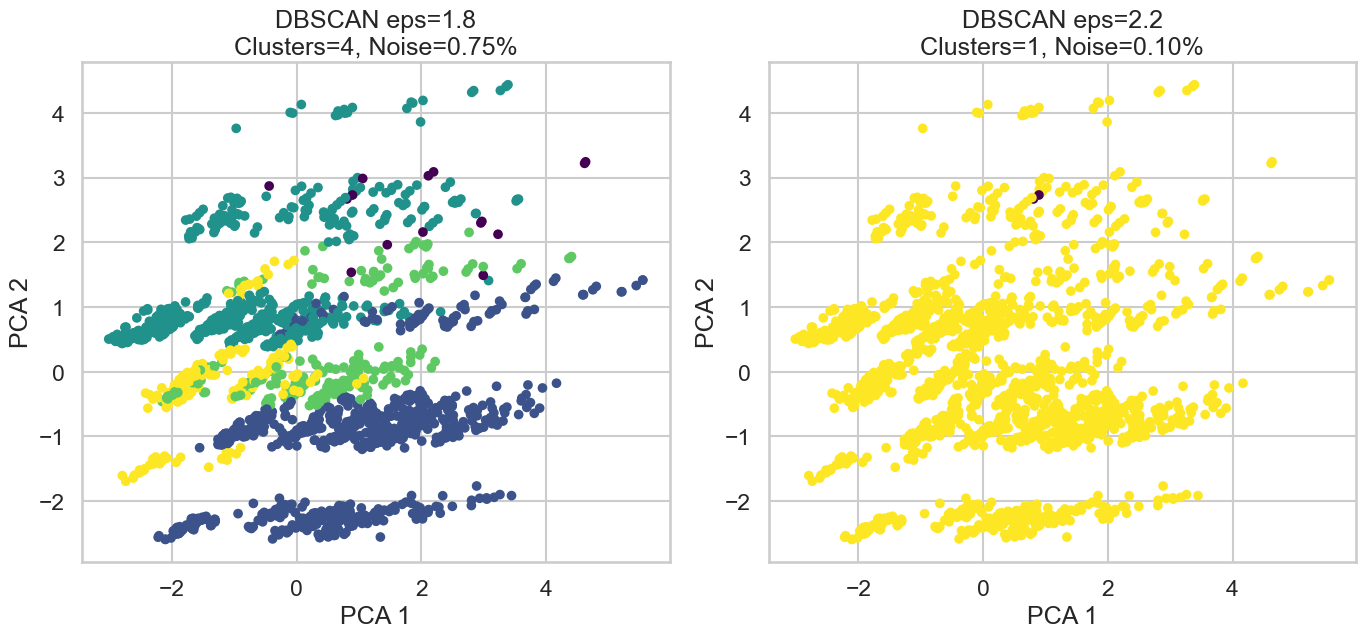

In [50]:
eps_values = [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.8, 2.2]

valid_results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=8)
    labels = db.fit_predict(X_customer_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    print(f"eps={eps}: clusters={n_clusters}, noise={noise_ratio:.2%}")

    if n_clusters <= 10 and n_clusters > 0:
        valid_results.append((eps, labels, n_clusters, noise_ratio))

if len(valid_results) == 0:
    print("No eps value produced 10 or fewer clusters. Try larger eps values.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, (eps, labels, n_clusters, noise_ratio) in enumerate(valid_results[:4]):
        axes[i].scatter(customer_pca[:, 0], customer_pca[:, 1], c=labels, cmap='viridis', s=30)
        axes[i].set_title(f'DBSCAN eps={eps}\nClusters={n_clusters}, Noise={noise_ratio:.2%}')
        axes[i].set_xlabel("PCA 1")
        axes[i].set_ylabel("PCA 2")

    for j in range(len(valid_results[:4]), 4):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

DBSCAN does not allow specifying the number of clusters directly. 
Instead, clusters emerge based on density parameters such as eps and min_samples.

To maintain interpretability for the customer dataset (which contains around 2000 samples), 
we limited visualizations to parameter settings producing at most 10 clusters. 
Configurations producing more clusters were ignored because they usually represent over-segmentation of the data.

# Final Conclusion

In this project, three clustering techniques were applied to three different datasets: Multi Blob, Iris, and Customer data.

### Main findings

**1. Multi Blob dataset**
- K-Means and Agglomerative clustering performed very well because the data naturally consists of compact blob-like groups.
- DBSCAN was more sensitive to parameter selection and did not always recover the expected 6 clusters.

**2. Iris dataset**
- K-Means and Hierarchical clustering gave meaningful results after scaling.
- DBSCAN was harder to tune and was less consistent.

**3. Customer dataset**
- Scaling was very important because features had different magnitudes.
- K-Means produced the most practical and interpretable segmentation.
- Hierarchical clustering also worked reasonably well.
- DBSCAN was less suitable for this type of data.

### Overall comparison
- **K-Means** works best for compact numeric clusters and is computationally efficient.
- **Agglomerative clustering** is useful for exploring hierarchical structure but depends on linkage choice.
- **DBSCAN** is powerful for density-based clustering and outlier detection, but is highly sensitive to its parameters.

### Effect of scaling
Scaling improved fairness in distance calculations, especially for the Iris and Customer datasets. Without scaling, variables with larger ranges can dominate the clustering process.